# YouTube Trending Videos: Question-Led Analysis

This notebook answers content, engagement, market, timing, persistence, and metadata questions from the 2017-18 historical trending snapshots.


## Interpretation guardrails

A row is a country-day trending snapshot. Counts of snapshots measure persistence as well as prevalence; counts of `unique_video_key` measure distinct country-video appearances. Results are descriptive associations, not causal estimates.


In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
CLEAN_PATH = ROOT / "data" / "processed" / "youtube_clean.csv"
if not CLEAN_PATH.exists():
    raise FileNotFoundError("Run 01_youtube_trending_eda.ipynb first to create data/processed/youtube_clean.csv")

df = pd.read_csv(CLEAN_PATH, parse_dates=["trending_date", "publish_date"])
numeric_columns = ["views", "likes", "dislikes", "comment_count", "engagement_rate", "likes_per_view", "comments_per_view", "dislikes_per_view", "days_to_trend", "days_trending", "trend_span_days", "market_count", "title_length", "title_word_count", "tag_count"]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")
video_level_df = (df.sort_values(["unique_video_key", "trending_date"], kind="mergesort")
                    .drop_duplicates("unique_video_key", keep="last").copy())
valid_df = df.loc[~df["metric_issue_flag"].fillna(False)].copy()
print(f"Snapshots: {len(df):,}; country-video records: {len(video_level_df):,}; valid-metric snapshots: {len(valid_df):,}")
display(df.head())


Snapshots: 161,470; country-video records: 63,805; valid-metric snapshots: 161,470


,index,video_id,trending_date,title,channel_title,category_id,publish_date,time_frame,published_day_of_week,publish_country,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed,engagement_rate,likes_per_view,comments_per_view,dislikes_per_view,like_ratio,days_to_trend,published_hour,publish_period,publish_month,trending_month,unique_video_key,category_label,tags_clean,tag_count,title_length,title_word_count,title_is_question,title_has_exclamation,title_has_all_caps_word,days_trending,trend_span_days,market_count,metric_issue_flag
0,0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13,17:00 to 17:59,Monday,US,SHANtell martin,748374,57527,2966,15954,False,False,False,0.098188,0.076869,0.021318,0.003963,0.950970,1,17,Afternoon,Nov,2017-11,US::2kyS6SvSYSE,People & Blogs,shantell martin,1,34,7,False,False,True,7,7,3,False
1,1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13,7:00 to 7:59,Monday,US,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,False,False,False,0.045431,0.040179,0.005252,0.002541,0.940521,1,7,Morning,Nov,2017-11,US::1ZAPwfrtAFY,Entertainment,last week tonight trump presidency|last week t...,4,62,10,False,False,True,7,7,2,False
2,2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12,19:00 to 19:59,Sunday,US,"racist superman|""rudy""""|""""mancuso""""|""""king""""|""...",3191434,146033,5339,8181,False,False,False,0.048321,0.045758,0.002563,0.001673,0.964729,2,19,Evening,Nov,2017-11,US::5qpjK5DgCt4,Comedy,racist superman|rudy|mancuso|king|bach|racist|...,23,53,8,False,False,False,7,7,2,False
3,3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13,11:00 to 11:59,Monday,US,"rhett and link|""gmm""""|""""good mythical morning""...",343168,10172,666,2146,False,False,False,0.035895,0.029641,0.006253,0.001941,0.938550,1,11,Morning,Nov,2017-11,US::puqaWrEC7tY,Entertainment,rhett and link|gmm|good mythical morning|rhett...,27,32,5,True,False,False,7,7,2,False
4,4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12,18:00 to 18:59,Sunday,US,"ryan|""higa""""|""""higatv""""|""""nigahiga""""|""""i dare ...",2095731,132235,1989,17518,False,False,False,0.071456,0.063097,0.008359,0.000949,0.985181,2,18,Evening,Nov,2017-11,US::d380meD0W0M,Entertainment,ryan|higa|higatv|nigahiga|i dare you|idy|rhpc|...,14,24,5,True,True,True,6,6,2,False


## Question 1: What types of content trend most often?

Both distinct country-video records and snapshot rows are shown so long-running videos do not inflate the apparent prevalence of a category.


,unique_videos,median_days_trending,snapshot_rows,video_share,snapshot_share
category_label,,,,,
Entertainment,18082,1.000000,42358,28.3%,26.2%
People & Blogs,7880,1.000000,15960,12.4%,9.9%
News & Politics,6574,1.000000,11623,10.3%,7.2%
Sports,5962,1.000000,11210,9.3%,6.9%
Music,5581,2.000000,27903,8.7%,17.3%
Comedy,5222,2.000000,13401,8.2%,8.3%
Howto & Style,3898,1.000000,10442,6.1%,6.5%
Film & Animation,3283,1.000000,9139,5.1%,5.7%
Gaming,2104,1.000000,5408,3.3%,3.3%


Answer: Entertainment has the most distinct country-video trends (18,082.0); Music has the longest median observed persistence (2 snapshots).


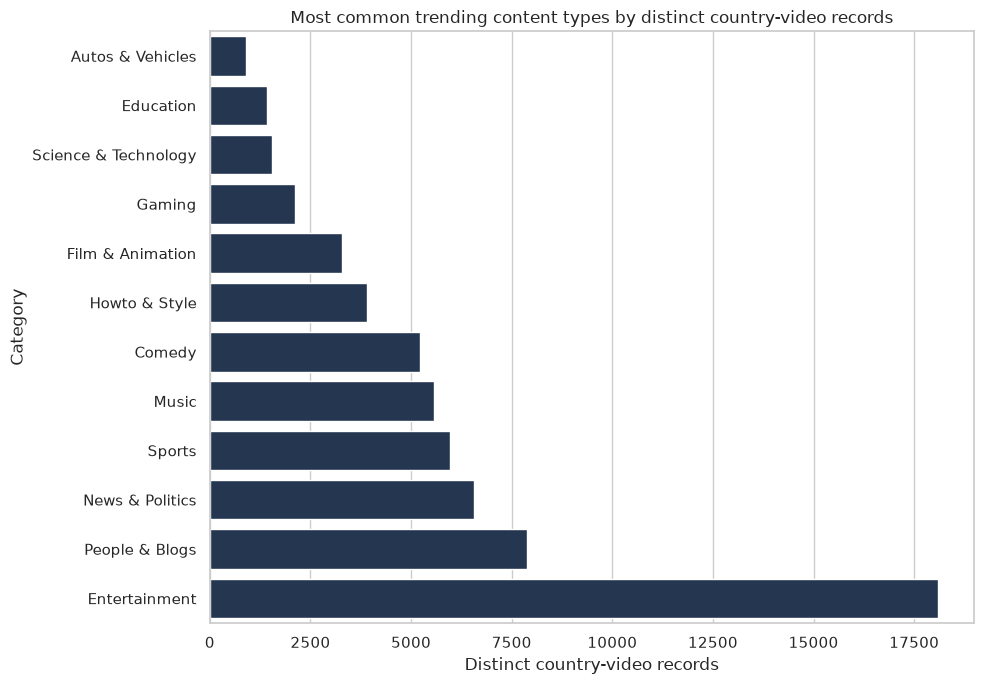

In [12]:
category_prevalence = (video_level_df.groupby("category_label")
    .agg(unique_videos=("unique_video_key", "size"), median_days_trending=("days_trending", "median"))
    .join(df.groupby("category_label").size().rename("snapshot_rows"))
    .assign(video_share=lambda x: x["unique_videos"] / len(video_level_df), snapshot_share=lambda x: x["snapshot_rows"] / len(df))
    .sort_values("unique_videos", ascending=False))
display(category_prevalence.head(12).style.format({"video_share": "{:.1%}", "snapshot_share": "{:.1%}"}))
leader = category_prevalence.index[0]
persistence_leader = category_prevalence["median_days_trending"].idxmax()
print(f"Answer: {leader} has the most distinct country-video trends ({category_prevalence.iloc[0]['unique_videos']:,}); {persistence_leader} has the longest median observed persistence ({category_prevalence.loc[persistence_leader, 'median_days_trending']:.0f} snapshots).")

plot_data = category_prevalence.head(12).sort_values("unique_videos")
plt.figure(figsize=(10, 7))
sns.barplot(data=plot_data, x="unique_videos", y=plot_data.index, color="#1d3557")
plt.title("Most common trending content types by distinct country-video records")
plt.xlabel("Distinct country-video records")
plt.ylabel("Category")
plt.tight_layout(); plt.show()


## Question 2: Which categories receive the most engagement?

Medians are preferred to averages because a small number of viral videos would otherwise dominate category comparisons. Categories need at least 100 distinct country-video records.


,unique_videos,median_views,median_engagement_rate,median_likes_per_view,median_comments_per_view,engagement_lift
category_label,,,,,,
Gaming,2104,"157,526",5.84%,5.09%,0.51%,+118.7%
Howto & Style,3898,"102,304",5.74%,5.17%,0.49%,+115.0%
Education,1420,"159,093",5.45%,4.80%,0.52%,+104.0%
Comedy,5222,"293,371",4.88%,4.45%,0.29%,+82.8%
Pets & Animals,579,"174,027",4.77%,4.11%,0.49%,+78.5%
Science & Technology,1557,"337,554",4.48%,3.87%,0.48%,+67.7%
Music,5581,"532,906",4.13%,3.82%,0.28%,+54.7%
Autos & Vehicles,907,"42,514",3.94%,3.38%,0.51%,+47.5%
Travel & Events,362,"226,348",3.42%,2.93%,0.42%,+28.1%


Answer: Gaming has the highest median interaction rate among sufficiently represented categories (5.84%), +118.7% versus the overall video median.


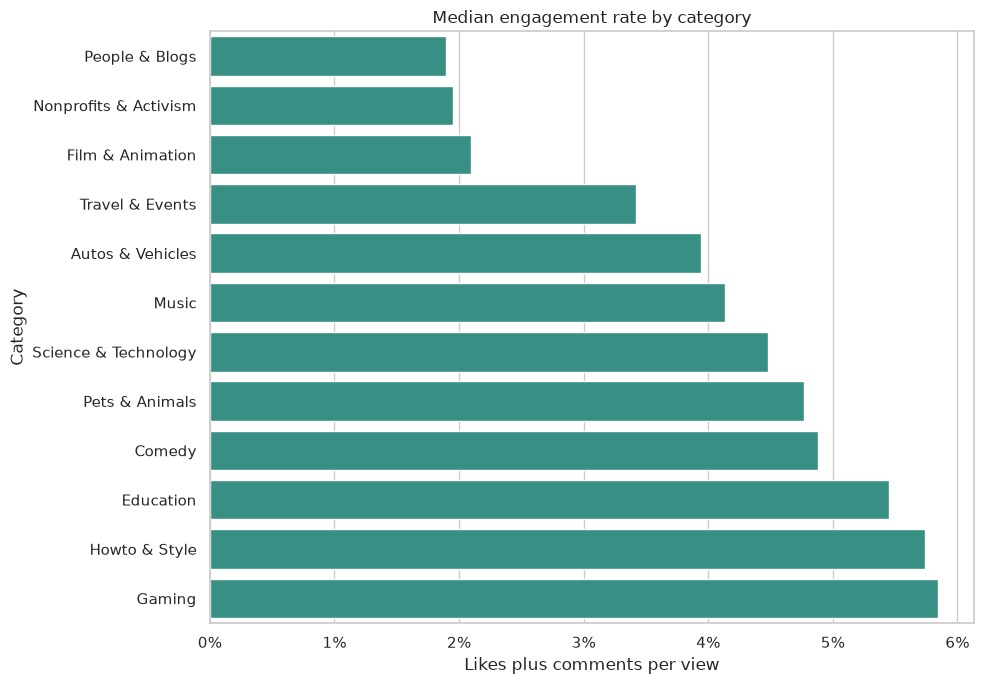

In [13]:
overall_median = video_level_df["engagement_rate"].median()
category_engagement = (video_level_df.groupby("category_label")
    .agg(unique_videos=("unique_video_key", "size"), median_views=("views", "median"), median_engagement_rate=("engagement_rate", "median"), median_likes_per_view=("likes_per_view", "median"), median_comments_per_view=("comments_per_view", "median"))
    .query("unique_videos >= 100")
    .assign(engagement_lift=lambda x: x["median_engagement_rate"] / overall_median - 1)
    .sort_values("median_engagement_rate", ascending=False))
display(category_engagement.style.format({"median_views": "{:,.0f}", "median_engagement_rate": "{:.2%}", "median_likes_per_view": "{:.2%}", "median_comments_per_view": "{:.2%}", "engagement_lift": "{:+.1%}"}))
engagement_leader = category_engagement.index[0]
print(f"Answer: {engagement_leader} has the highest median interaction rate among sufficiently represented categories ({category_engagement.iloc[0]['median_engagement_rate']:.2%}), {category_engagement.iloc[0]['engagement_lift']:+.1%} versus the overall video median.")

plot_data = category_engagement.head(12).sort_values("median_engagement_rate")
plt.figure(figsize=(10, 7))
sns.barplot(data=plot_data, x="median_engagement_rate", y=plot_data.index, color="#2a9d8f")
plt.gca().xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
plt.title("Median engagement rate by category")
plt.xlabel("Likes plus comments per view"); plt.ylabel("Category")
plt.tight_layout(); plt.show()


## Question 3: Do content patterns differ by market?

The heatmap shows each category's share of a market's distinct country-video records. This compares composition rather than raw market dataset size.


,leading_category,share
publish_country,,
CANADA,Entertainment,33.7%
FRANCE,Entertainment,24.8%
GB,Music,26.9%
US,Entertainment,25.6%


Answer: market leaders differ; use the composition heatmap rather than pooled counts when targeting a specific market.


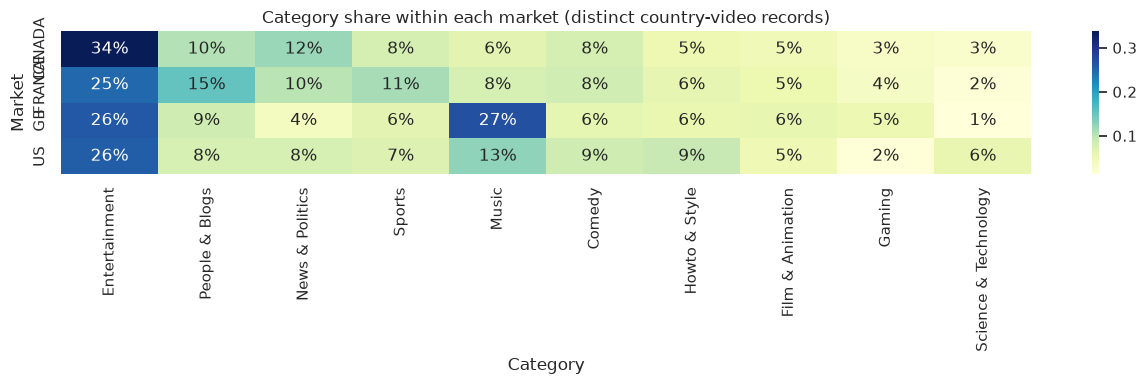

In [14]:
market_category = pd.crosstab(video_level_df["publish_country"], video_level_df["category_label"], normalize="index")
leading_by_market = market_category.idxmax(axis=1).rename("leading_category").to_frame()
leading_by_market["share"] = market_category.max(axis=1)
display(leading_by_market.style.format({"share": "{:.1%}"}))
print("Answer: market leaders differ; use the composition heatmap rather than pooled counts when targeting a specific market.")

selected_categories = category_prevalence.head(10).index
plt.figure(figsize=(13, 4))
sns.heatmap(market_category.reindex(columns=selected_categories), annot=True, fmt=".0%", cmap="YlGnBu")
plt.title("Category share within each market (distinct country-video records)")
plt.xlabel("Category"); plt.ylabel("Market")
plt.tight_layout(); plt.show()


## Question 4: How quickly do videos trend, and what publishing windows are represented?

Publishing hour comes from the source's recorded time frame. Its timezone is not documented, so it should be used for descriptive comparison only.


In [15]:
video_level_df["time_to_trend_band"] = pd.cut(video_level_df["days_to_trend"], [-1, 0, 1, 7, 30, np.inf], labels=["Same day", "1 day", "2-7 days", "8-30 days", "31+ days"])
timing_summary = (video_level_df.groupby("time_to_trend_band", observed=False)
    .agg(videos=("unique_video_key", "size"), median_engagement_rate=("engagement_rate", "median"), median_days_trending=("days_trending", "median"))
    .assign(share=lambda x: x["videos"] / x["videos"].sum()))
display(timing_summary.style.format({"share": "{:.1%}", "median_engagement_rate": "{:.2%}"}))
print(f"Answer: {timing_summary['share'].idxmax()} is the most common time-to-trend band ({timing_summary['share'].max():.1%} of country-video records).")

period_summary = (video_level_df.groupby("publish_period", observed=False)
    .agg(videos=("unique_video_key", "size"), median_engagement_rate=("engagement_rate", "median"))
    .dropna())
display(period_summary.style.format({"median_engagement_rate": "{:.2%}"}))


,videos,median_engagement_rate,median_days_trending,share
time_to_trend_band,,,,
Same day,1533,3.03%,1.000000,2.4%
1 day,31841,2.46%,1.000000,49.9%
2-7 days,24895,2.89%,2.000000,39.0%
8-30 days,4838,2.74%,10.000000,7.6%
31+ days,698,1.32%,17.000000,1.1%


Answer: 1 day is the most common time-to-trend band (49.9% of country-video records).


,videos,median_engagement_rate
publish_period,,
Afternoon,26791,3.18%
Evening,19642,2.62%
Morning,9235,2.29%
Night,8137,1.94%


## Question 5: Are recurring videos different from one-day trends?

Trend persistence is measured by the number of source snapshots for a country-video record, not by an uninterrupted global trending run.


,videos,median_views,median_engagement_rate,median_comments_per_view,share
persistence_group,,,,,
1 snapshot,37934,"74,949",2.31%,0.32%,59.5%
2-3 snapshots,16587,"335,752",3.18%,0.31%,26.0%
4-7 snapshots,5348,"841,574",3.00%,0.28%,8.4%
8+ snapshots,3936,"1,047,945",2.81%,0.24%,6.2%


Answer: compare the persistence groups above as observed associations; repeated snapshots can reflect both audience response and platform selection.


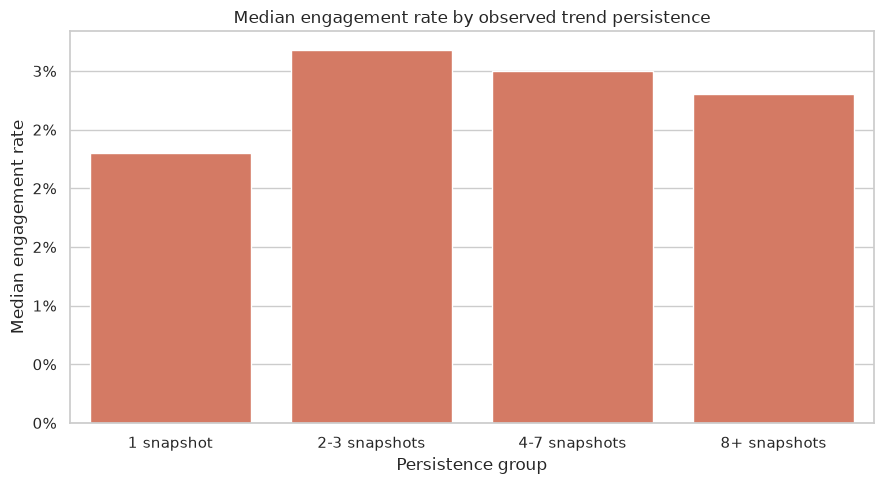

In [16]:
video_level_df["persistence_group"] = pd.cut(video_level_df["days_trending"], [0, 1, 3, 7, np.inf], labels=["1 snapshot", "2-3 snapshots", "4-7 snapshots", "8+ snapshots"])
persistence_summary = (video_level_df.groupby("persistence_group", observed=False)
    .agg(videos=("unique_video_key", "size"), median_views=("views", "median"), median_engagement_rate=("engagement_rate", "median"), median_comments_per_view=("comments_per_view", "median"))
    .assign(share=lambda x: x["videos"] / x["videos"].sum()))
display(persistence_summary.style.format({"share": "{:.1%}", "median_views": "{:,.0f}", "median_engagement_rate": "{:.2%}", "median_comments_per_view": "{:.2%}"}))
print("Answer: compare the persistence groups above as observed associations; repeated snapshots can reflect both audience response and platform selection.")

plt.figure(figsize=(9, 5))
sns.barplot(data=persistence_summary.reset_index(), x="persistence_group", y="median_engagement_rate", color="#e76f51")
plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
plt.title("Median engagement rate by observed trend persistence")
plt.xlabel("Persistence group"); plt.ylabel("Median engagement rate")
plt.tight_layout(); plt.show()


## Question 6: Which title and tag characteristics are associated with stronger engagement?

These comparisons describe metadata associations only. Tag results require at least 30 video records to limit unstable niche-tag rankings.


In [17]:
title_features = ["title_is_question", "title_has_exclamation", "title_has_all_caps_word"]
title_summary = pd.concat([
    video_level_df.groupby(feature, dropna=False).agg(videos=("unique_video_key", "size"), median_engagement_rate=("engagement_rate", "median"), median_views=("views", "median")).assign(feature=feature).reset_index().rename(columns={feature: "present"})
    for feature in title_features
], ignore_index=True)
display(title_summary.style.format({"median_engagement_rate": "{:.2%}", "median_views": "{:,.0f}"}))

tag_frame = video_level_df.loc[video_level_df["tags_clean"].fillna("") != "", ["tags_clean", "engagement_rate", "views"]].copy()
tag_frame = tag_frame.assign(tag=tag_frame["tags_clean"].str.split("|")).explode("tag")
tag_metrics = (tag_frame.groupby("tag")
    .agg(videos=("tag", "size"), median_engagement_rate=("engagement_rate", "median"), median_views=("views", "median"))
    .query("videos >= 30")
    .sort_values("median_engagement_rate", ascending=False))
display(tag_metrics.head(15).style.format({"median_engagement_rate": "{:.2%}", "median_views": "{:,.0f}"}))
print(f"Answer: the top stable tag by median engagement is '{tag_metrics.index[0]}' ({tag_metrics.iloc[0]['median_engagement_rate']:.2%}, n={tag_metrics.iloc[0]['videos']:,}). Treat this as an association, not a content prescription.")


,present,videos,median_engagement_rate,median_views,feature
0,False,60157,2.58%,"167,733",title_is_question
1,True,3648,4.34%,"98,034",title_is_question
2,False,54959,2.37%,"168,947",title_has_exclamation
3,True,8846,4.88%,"131,530",title_has_exclamation
4,False,38278,2.08%,"174,614",title_has_all_caps_word
5,True,25527,3.90%,"146,895",title_has_all_caps_word


,videos,median_engagement_rate,median_views
tag,,,
hahaha,32,17.97%,"45,125"
tomlitv,32,17.97%,"45,125"
deuxiã¨me,32,17.54%,"45,125"
lafontaine,31,17.54%,"45,125"
quebecois,31,17.54%,"45,125"
vloggeur,31,17.54%,"45,125"
gauthier,31,17.54%,"45,125"
hilarant,34,17.38%,"45,546"
absurde,40,17.22%,"45,125"


Answer: the top stable tag by median engagement is 'hahaha' (17.97%, n=32.0). Treat this as an association, not a content prescription.


## Conclusions and limitations

- Category prevalence, category engagement, and market composition answer different questions and should not be conflated.
- Engagement comparisons use medians to reduce the influence of viral outliers; category and tag comparisons use minimum sample thresholds.
- The archive covers historical snapshots from November 2017 to June 2018 in four markets. It cannot establish what trends today, causal effects, or a globally synchronized ranking.
- For content planning, use the category and market tables to form hypotheses, then validate them with current audience and campaign data.
